Starting Monte Carlo simulation...
0.001% completed, estimated time remaining: 2h 6m 49.4s
0.010% completed, estimated time remaining: 1h 57m 58.8s
0.100% completed, estimated time remaining: 1h 51m 11.4s
1.000% completed, estimated time remaining: 1h 58m 33.6s
5.000% completed, estimated time remaining: 1h 55m 46.0s
10.000% completed, estimated time remaining: 1h 57m 29.5s
20.000% completed, estimated time remaining: 1h 44m 40.3s
50.000% completed, estimated time remaining: 1h 3m 38.7s
75.000% completed, estimated time remaining: 0h 32m 28.3s
90.000% completed, estimated time remaining: 0h 13m 3.6s
100.000% completed, estimated time remaining: 0h 0m 0.0s
Simulation completed in 2h 10m 21.7s.
At time t = 50.000000, the mean number operator <n> = 0.95682370289456719625320602062856778502464294433594


c:\Users\Mi PC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Full mesolve result info:
<Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 0.0019214153289794922
    preparation time: 0.0018582344055175781
    run time: 4.559746503829956
    solver: 'Master Equation Evolution'
    num_collapse: 1
  Time interval: [0.0, 50.0] (10001 steps)
  Number of e_ops: 1
  State not saved.
>
mesolve n at t=50.000000 is 0.95646304690198347131513401109259575605392456054688
RMSE between Manual MC and mesolve: 0.005047


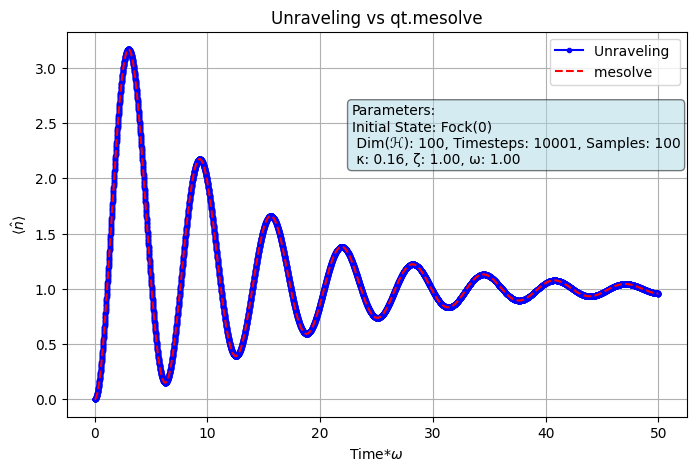

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import time  
import cmath 

def format_time(seconds): #Convert seconds to hours, minutes, seconds format.
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = seconds % 60
    return f"{hours}h {minutes}m {secs:.1f}s"
# Function to define operators for dimension N (all are Qobj)
def define_operators(N):
    a = qt.destroy(N)          # Annihilation operator
    a_dag = qt.create(N)       # Creation operator (Hermitian conjugate of a)
    n = qt.num(N)              # Number operator n = a_dag * a
    x = qt.position(N)         # Position operator x = (a + a_dag) / sqrt(2)
    p = qt.momentum(N)         # Momentum operator p = -1j * (a - a_dag) / sqrt(2)
    return a, a_dag, n, x, p

def time_dependent_F(dt):
    omega = 1 #to allow time scaling to de dimensionless
    #omega = cmath.pi  # Old Frequency to calculate n for t=10
    zeta = (cmath.pi**2 + (cmath.log(2)/10)**2) * 0 +1 # Driving frequency
    kappa = (2 * cmath.log(2) / 10) * 0 +cmath.pi/20   # Damping rate
    Wn=(omega-1j*kappa/2)*1
    F_N=Wn*dt
    F_plus=(zeta/Wn)*cmath.sin(Wn*dt)
    F_minus=(zeta/Wn)*(1-cmath.cos(Wn*dt))
    F_I= (zeta/Wn)**2 *(0.5*cmath.sin(2*Wn*dt)-Wn*dt)
    return Wn, F_N, F_plus, F_minus, F_I

# User input: Select Hilbert space dimension N
N = int(input("Enter the Hilbert space dimension N: "))

# Define operators based on N
a, a_dag, n, x, p = define_operators(N)

# Define Hamiltonian H
omega = cmath.pi*0 +1 # Frequency
zeta = (cmath.pi**2 + (cmath.log(2)/10)**2) * 0 +1 # Driving frequency

H = omega * n + zeta * (a_dag + a)


# Define Lindblad operators Ls
kappa = (2 * cmath.log(2) / 10) * 0 +cmath.pi/20  # Damping rate
Ls = [cmath.sqrt(kappa) * a]  # Single Lindblad for photon loss

# Compute effective Hamiltonian Heff (non-Hermitian) (not used in the current implementation but defined for completeness)
#Heff = H - 1j / 2 * sum([L.dag() * L for L in Ls])

# Define initial state psi0
psi0 = qt.basis(N, 0)  # Vacuum state |0>
initial_state_str = f"Fock(0)"

# Time list (Fewer timesteps can cause numerical inestabilities)
timestep=1+10**4
final_time =50
tlist = np.linspace(0, final_time, timestep)  # Reduced for faster testing; increase for finer dt
dt_list = np.diff(tlist)  # Time steps

sample = 100
mean_n = np.zeros(len(tlist), dtype=complex)
milestones = [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 75, 90, 100]
milestone_index = 0
start_time = time.time()
total_steps = sample * (len(tlist) - 1)
current_step = 0

print("Starting Monte Carlo simulation...")


for count in range(sample):
    psi = psi0
    n_expect_list = [qt.expect(n, psi)]
    
    for i in range(1, len(tlist)):
        dt = dt_list[i-1]
        t_current = tlist[i]
        u = np.random.random()

        dps = [np.real(dt * qt.expect(L.dag() * L, psi)) for L in Ls]
        dP = np.sum(dps)
        
        if dP < u:
            Wn, F_N, F_plus, F_minus, F_I = time_dependent_F(dt)
            current_alpha = qt.expect(a, psi)
            alpha_new = (current_alpha  -1j*F_plus + F_minus) *cmath.exp(-1j*F_N)
            exp_factor = -1j*F_I - 1j*F_plus*F_minus - 0.5*((F_plus)**2  +F_minus**2) - (1j*F_plus + F_minus)*current_alpha - 0.5*abs(current_alpha)**2 + 0.5*abs(alpha_new)**2
            psi = cmath.exp(exp_factor) * qt.coherent(N, alpha_new)
            
            
            #evol_op =  np.exp(-1j*F_I)*(-1j*F_N*n).expm()*  (-1j*F_plus*(a_dag+a)).expm() *  (F_minus*(a_dag-a)).expm() 
            #evol_op = np.exp(-1j*(F_I+F_minus*F_plus)) * (-1j*F_N*n).expm() * ((F_minus-1j*F_plus)*a_dag-(F_minus+1j*F_plus)*a).expm()
            #psi = (-1j*H*dt).expm() * psi


            #Normalization
            norm_val = psi.norm()
            if norm_val > 0:
                psi = psi / norm_val
            else:
                print(f"Warning: Zero norm at step {i}, trajectory {count}")
                break
        else:
            u_jump = np.random.random()
            Q = np.cumsum(dps) / dP
            k = np.searchsorted(Q, u_jump, side='left')
            psi = Ls[k] * psi

            norm_val = psi.norm()
            if norm_val > 0:
                psi = psi / norm_val
        
        n_expect_list.append(qt.expect(n, psi))
        
        current_step += 1
        progress = (current_step / total_steps) * 100
        if milestone_index < len(milestones) and progress >= milestones[milestone_index]:
            elapsed_time = time.time() - start_time
            estimated_total_time = elapsed_time / (progress / 100)
            remaining_time = estimated_total_time - elapsed_time
            print(f"{milestones[milestone_index]:.3f}% completed, estimated time remaining: {format_time(remaining_time)}")
            milestone_index += 1
    
    while len(n_expect_list) < len(tlist):
        n_expect_list.append(n_expect_list[-1])
    
    mean_n += np.array(n_expect_list)

mean_n /= sample
total_time = time.time() - start_time
print(f"Simulation completed in {format_time(total_time)}.")
index = np.argmin(np.abs(tlist - final_time))
print(f"At time t = {tlist[index]:.6f}, the mean number operator <n> = {np.real(mean_n[index]):.50f}")


# Evolución determinista equivalente (sin Monte Carlo)
mesolve_start_time = time.time()
result_mesolve = qt.mesolve(H, psi0, tlist, Ls, [n])
mesolve_time = time.time() - mesolve_start_time
mean_n_mesolve = result_mesolve.expect[0]
print(f"Full mesolve result info:\n{result_mesolve}")
print(f"mesolve n at t={tlist[index]:.6f} is {mean_n_mesolve[index]:.50f}")


# Compute RMSE between Manual MC and mesolve results
rmse = np.sqrt(np.mean((np.real(mean_n) - mean_n_mesolve)**2))
print(f"RMSE between Manual MC and mesolve: {rmse:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(tlist, np.real(mean_n), '.-b', label=f"Unraveling ")
plt.plot(tlist, mean_n_mesolve, '--r', label=f"mesolve ") #deterministic (only 1 "sample")
plt.xlabel(r'Time*$\omega$')
plt.ylabel(r'$\langle \hat{n} \rangle$')
plt.title('Unraveling vs qt.mesolve')
plt.legend()
plt.grid(True)

param_text = f"Parameters:\nInitial State: {initial_state_str}\n Dim(ℋ): {N}, Timesteps: {timestep}, Samples: {sample}\n κ: {kappa.real:.2f}, ζ: {zeta.real:.2f}, ω: {omega.real:.2f}"
plt.text(0.46, 0.65, param_text, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='bottom', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

plt.show()


In [ ]:
import pandas as pd
import os

# CSV file path
csv_file = "simulation_results.csv"

# Prepare data for both methods
data_to_append = [
    {
        "method": f"Unraveling z= {zeta.real} k={kappa.real:.3f}",
        "initial_state": initial_state_str, 
        "dimension": N,
        "timesteps": timestep,
        "samples": sample,
        "total_simulation_time": total_time,
        "accuracy": rmse
    },
    {
        "method": f"mesolve z={zeta.real} k={kappa.real:.3f}",
        "initial_state": initial_state_str,
        "dimension": N,
        "timesteps": timestep,
        "samples": 1,  # mesolve is deterministic
        "total_simulation_time": mesolve_time,
        "accuracy": None
    }
]

# Create DataFrame from the data
df_new = pd.DataFrame(data_to_append)

# Check if file exists, if yes append, if no create new
if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    df_combined.to_csv(csv_file, index=False)
    print(f"Data appended to {csv_file}")
else:
    df_new.to_csv(csv_file, index=False)
    print(f"New {csv_file} created with simulation data")

# Display the current contents of the CSV
print(f"\nCurrent contents of {csv_file}:")
print(pd.read_csv(csv_file))

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Extract numerical results at t=10
index_t10 = np.argmin(np.abs(tlist - 10.0))
t_result = tlist[index_t10]
mesolve_result_t10 = mean_n_mesolve[index_t10]
unraveling_result_t10 = np.real(mean_n[index_t10])

print("="*60)
print(f"Results at time t = {t_result:.6f}")
print("="*60)
print(f"mesolve <n>:      {mesolve_result_t10:.15f}")
print(f"Unraveling <n>:   {unraveling_result_t10:.15f}")
print(f"Difference:       {abs(mesolve_result_t10 - unraveling_result_t10):.15e}")
print("="*60)

# Save to a results file
results_t10 = {
    'time': t_result,
    'mesolve_expect_n': mesolve_result_t10,
    'unraveling_expect_n': unraveling_result_t10,
    'difference': abs(mesolve_result_t10 - unraveling_result_t10),
    'parameters': {
        'N': N,
        'timesteps': timestep,
        'samples': sample,
        'zeta': zeta,
        'kappa': kappa
    }
}

# Display results
import json
print("\nResults as JSON:")
print(json.dumps(results_t10, indent=2, default=str))